In [3]:
import pandas as pd
import numpy as np
from google.colab import files

# =====================================================================
# BLOQUE 1: CARGA INTERACTIVA Y PARTICIÓN DE DATOS PARA DLF
# =====================================================================

print("Por favor, seleccione los 4 archivos CSV (TAMPICO.csv, HOUSTON.csv, MIAMI.csv, MATAMOROS.csv):")
# Esto abrirá el selector de archivos
uploaded = files.upload()

# Verificación de carga
for fn in uploaded.keys():
    print('Archivo cargado: "{name}" con un tamaño de {length} bytes'.format(
        name=fn, length=len(uploaded[fn])))

print("\n--- Iniciando partición de datos para DLF ---")

ciudades = ['TAMPICO', 'HOUSTON', 'MIAMI', 'MATAMOROS']

# Mismos tamaños de partición rigurosos usados en la Etapa 1
n_train = 227
n_val = 65
n_test = 32

# Diccionario maestro para almacenar las series de tiempo
datos_dlf = {}

for city in ciudades:
    filename = f'{city}.csv'
    if filename in uploaded:
        # Leer el CSV. Usamos iloc[:, 1] para tomar directamente
        # la segunda columna (temperatura) sin importar el nombre del header.
        df = pd.read_csv(filename)
        series = df.iloc[:, 1].values

        # Partición estricta
        train = series[:n_train]
        val = series[n_train:n_train + n_val]
        test = series[n_train + n_val:n_train + n_val + n_test]
        history = np.concatenate((train, val)) # Historia completa antes del Test

        # Almacenar en el diccionario maestro
        datos_dlf[city] = {
            'train': train,
            'val': val,
            'test': test,
            'history': history,
            'full_series': series
        }

        print(f"[{city}] Procesado con éxito -> Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")
    else:
        print(f"[ERROR] Falta el archivo '{filename}'. Asegúrese de haberlo subido.")

print("-----------------------------------------")
print("Estructura de datos lista. Variables almacenadas en el diccionario 'datos_dlf'.")

Por favor, seleccione los 4 archivos CSV (TAMPICO.csv, HOUSTON.csv, MIAMI.csv, MATAMOROS.csv):


Saving TAMPICO.csv to TAMPICO.csv
Saving HOUSTON.csv to HOUSTON.csv
Saving MATAMOROS.csv to MATAMOROS.csv
Saving MIAMI.csv to MIAMI.csv
Archivo cargado: "TAMPICO.csv" con un tamaño de 7524 bytes
Archivo cargado: "HOUSTON.csv" con un tamaño de 5454 bytes
Archivo cargado: "MATAMOROS.csv" con un tamaño de 5474 bytes
Archivo cargado: "MIAMI.csv" con un tamaño de 5450 bytes

--- Iniciando partición de datos para DLF ---
[TAMPICO] Procesado con éxito -> Train: 227 | Val: 65 | Test: 32
[HOUSTON] Procesado con éxito -> Train: 227 | Val: 65 | Test: 32
[MIAMI] Procesado con éxito -> Train: 227 | Val: 65 | Test: 32
[MATAMOROS] Procesado con éxito -> Train: 227 | Val: 65 | Test: 32
-----------------------------------------
Estructura de datos lista. Variables almacenadas en el diccionario 'datos_dlf'.


--- Aplicando Filtros de Descomposición (MA3, MA6, Fk) ---
[ÉXITO] Los 3 filtros y sus residuales han sido calculados y almacenados.


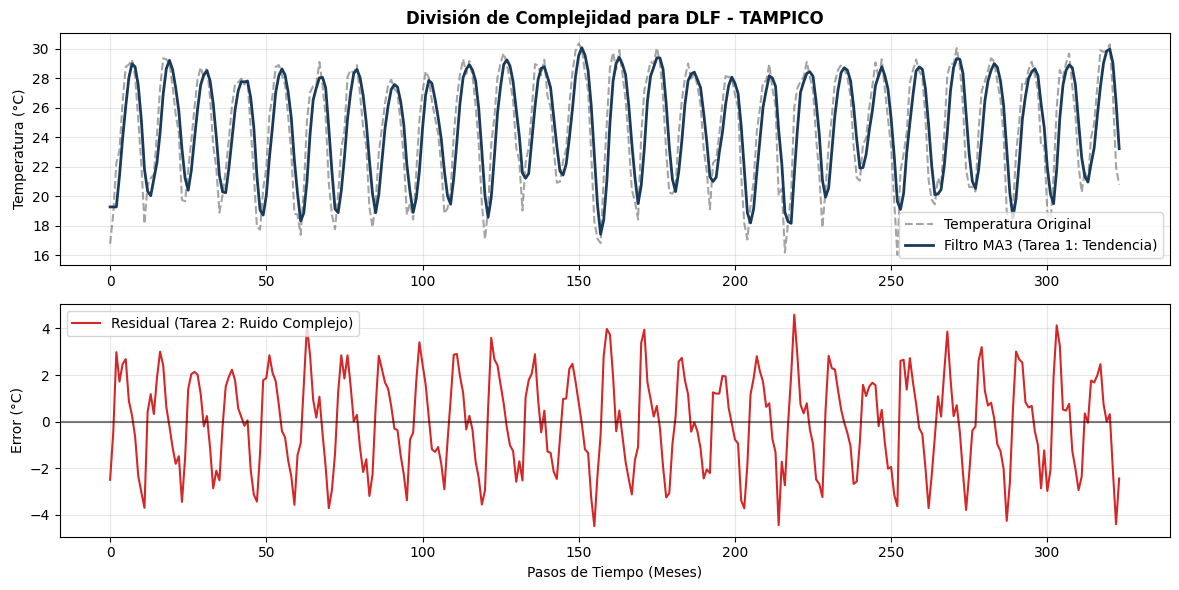

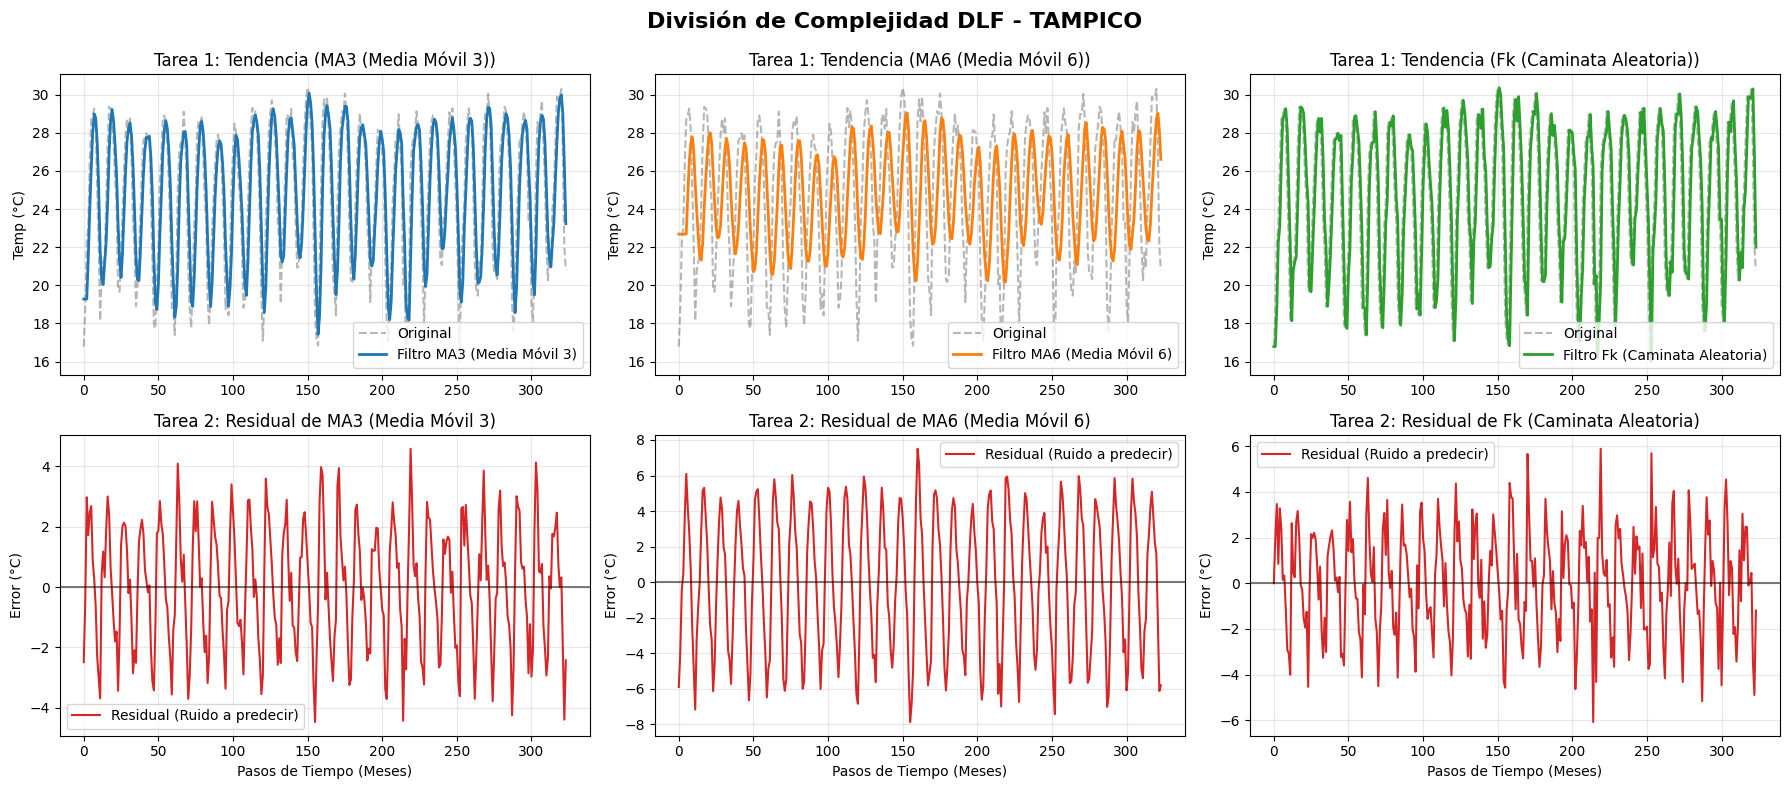

In [4]:
import matplotlib.pyplot as plt

# =====================================================================
# BLOQUE 2: DESCOMPOSICIÓN POR FILTROS (Divide and Conquer para DLF)
# =====================================================================
print("--- Aplicando Filtros de Descomposición (MA3, MA6, Fk) ---")

for city, data in datos_dlf.items():
    series = data['full_series']

    # 1. Filtro MA3 (Media Móvil de 3 meses)
    ma3 = pd.Series(series).rolling(window=3).mean().bfill().values

    # 2. Filtro MA6 (Media Móvil de 6 meses)
    ma6 = pd.Series(series).rolling(window=6).mean().bfill().values

    # 3. Filtro Fk (Caminata Aleatoria / Naive: Y_t = Y_{t-1})
    fk = np.roll(series, shift=1)
    fk[0] = series[0]  # Rellenar el primer valor para evitar desbordamiento

    # Guardar los filtros (TAREA 1: Señal Suavizada)
    datos_dlf[city]['ma3'] = ma3
    datos_dlf[city]['ma6'] = ma6
    datos_dlf[city]['fk'] = fk

    # Guardar los residuales (TAREA 2: Ruido de Alta Frecuencia)
    # Fórmula: Original = Filtro + Residual
    datos_dlf[city]['res_ma3'] = series - ma3
    datos_dlf[city]['res_ma6'] = series - ma6
    datos_dlf[city]['res_fk'] = series - fk

print("[ÉXITO] Los 3 filtros y sus residuales han sido calculados y almacenados.")

# =====================================================================
# GRÁFICA DE DIAGNÓSTICO (Para visualizar la división de tareas)
# =====================================================================
# Tomamos la primera ciudad cargada como ejemplo
ciudad_ejemplo = ciudades[0]
s_ejemplo = datos_dlf[ciudad_ejemplo]['full_series']
filtro_ejemplo = datos_dlf[ciudad_ejemplo]['ma3']
residual_ejemplo = datos_dlf[ciudad_ejemplo]['res_ma3']

plt.figure(figsize=(12, 6))

# Tarea 1: Señal Base
plt.subplot(2, 1, 1)
plt.plot(s_ejemplo, label='Temperatura Original', color='#4A4A4A', alpha=0.5, linestyle='--')
plt.plot(filtro_ejemplo, label='Filtro MA3 (Tarea 1: Tendencia)', color='#1A3A5A', linewidth=2)
plt.title(f'División de Complejidad para DLF - {ciudad_ejemplo}', fontsize=12, fontweight='bold')
plt.ylabel('Temperatura (°C)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# Tarea 2: Residual a Modelar por DL
plt.subplot(2, 1, 2)
plt.plot(residual_ejemplo, label='Residual (Tarea 2: Ruido Complejo)', color='#D62728', linewidth=1.5)
plt.axhline(0, color='black', linestyle='-', alpha=0.5)
plt.ylabel('Error (°C)')
plt.xlabel('Pasos de Tiempo (Meses)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =====================================================================
# GRÁFICA DE DIAGNÓSTICO COMPLETA (3 Filtros x 2 Tareas)
# =====================================================================
# Tomamos la primera ciudad cargada como ejemplo (puede cambiar el índice)
ciudad_ejemplo = ciudades[0]
s_ejemplo = datos_dlf[ciudad_ejemplo]['full_series']

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle(f'División de Complejidad DLF - {ciudad_ejemplo}', fontsize=16, fontweight='bold')

filtros_keys = ['ma3', 'ma6', 'fk']
titulos = ['MA3 (Media Móvil 3)', 'MA6 (Media Móvil 6)', 'Fk (Caminata Aleatoria)']
colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

for i, (f_key, titulo, color) in enumerate(zip(filtros_keys, titulos, colores)):
    filtro_val = datos_dlf[ciudad_ejemplo][f_key]
    res_val = datos_dlf[ciudad_ejemplo][f'res_{f_key}']

    # Fila 0: Tarea 1 (Señal Suavizada / Tendencia)
    axes[0, i].plot(s_ejemplo, label='Original', color='#4A4A4A', alpha=0.4, linestyle='--')
    axes[0, i].plot(filtro_val, label=f'Filtro {titulo}', color=color, linewidth=2)
    axes[0, i].set_title(f'Tarea 1: Tendencia ({titulo})', fontsize=12)
    axes[0, i].set_ylabel('Temp (°C)')
    axes[0, i].legend(loc='best')
    axes[0, i].grid(True, alpha=0.3)

    # Fila 1: Tarea 2 (Residual / Alta Frecuencia)
    axes[1, i].plot(res_val, label='Residual (Ruido a predecir)', color='#D62728', linewidth=1.5)
    axes[1, i].axhline(0, color='black', linestyle='-', alpha=0.5)
    axes[1, i].set_title(f'Tarea 2: Residual de {titulo}', fontsize=12)
    axes[1, i].set_xlabel('Pasos de Tiempo (Meses)')
    axes[1, i].set_ylabel('Error (°C)')
    axes[1, i].legend(loc='best')
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.subplots_adjust(top=0.9) # Ajuste para que el título principal no se empalme
plt.show()

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

def build_strict_trend_lstm(input_shape):
    """
    Arquitectura diseñada para sobreajustar (memorizar) tendencias y señales
    de baja frecuencia (MA3, MA6), sin regularización (sin Dropout).
    """
    model = Sequential([
        # Capa 1: Extrae la dinámica base (return_sequences=True para apilar)
        LSTM(128, activation='tanh', return_sequences=True, input_shape=input_shape),

        # Capa 2: Extrae la "aceleración" o curvatura de la tendencia
        LSTM(64, activation='tanh', return_sequences=False),

        # Capa Densa: Ajuste fino estricto a la salida
        Dense(32, activation='relu'),

        # Salida lineal
        Dense(1)
    ])

    # Usamos Huber loss o MSE. MSE es más estricto con las desviaciones.
    model.compile(optimizer='adam', loss='mse')
    return model


🏙️ EVALUANDO FILTROS PARA: TAMPICO
  -> Entrenando LSTM con: MA3...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     RMSE: 0.7379 | MASE: 0.2980 | DA: 96.15%
  -> Entrenando LSTM con: MA6...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     RMSE: 0.6005 | MASE: 0.2658 | DA: 92.31%
  -> Entrenando LSTM con: FK...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     RMSE: 1.2657 | MASE: 0.5286 | DA: 82.69%
🏆 GANADOR (TAMPICO): MA6 con MASE de 0.2658


/tmp/ipykernel_22835/207952305.py:111: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


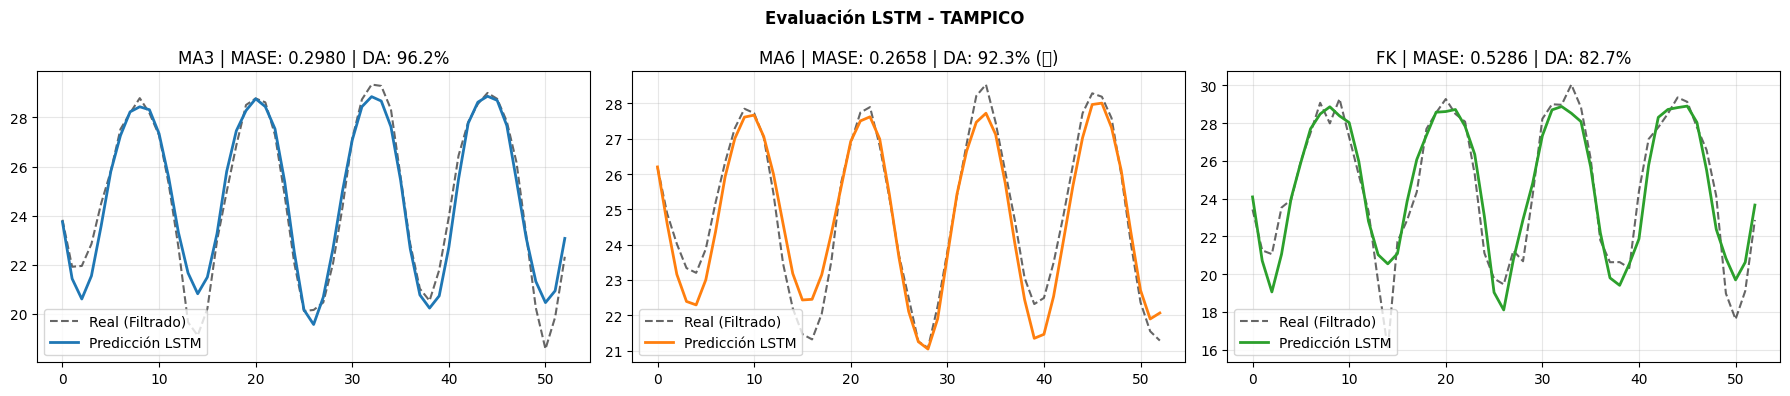

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🏙️ EVALUANDO FILTROS PARA: HOUSTON
  -> Entrenando LSTM con: MA3...
     RMSE: 0.9977 | MASE: 0.3930 | DA: 96.15%
  -> Entrenando LSTM con: MA6...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     RMSE: 0.9050 | MASE: 0.3528 | DA: 94.23%
  -> Entrenando LSTM con: FK...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     RMSE: 1.8887 | MASE: 0.7491 | DA: 86.54%
🏆 GANADOR (HOUSTON): MA6 con MASE de 0.3528


/tmp/ipykernel_22835/207952305.py:111: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


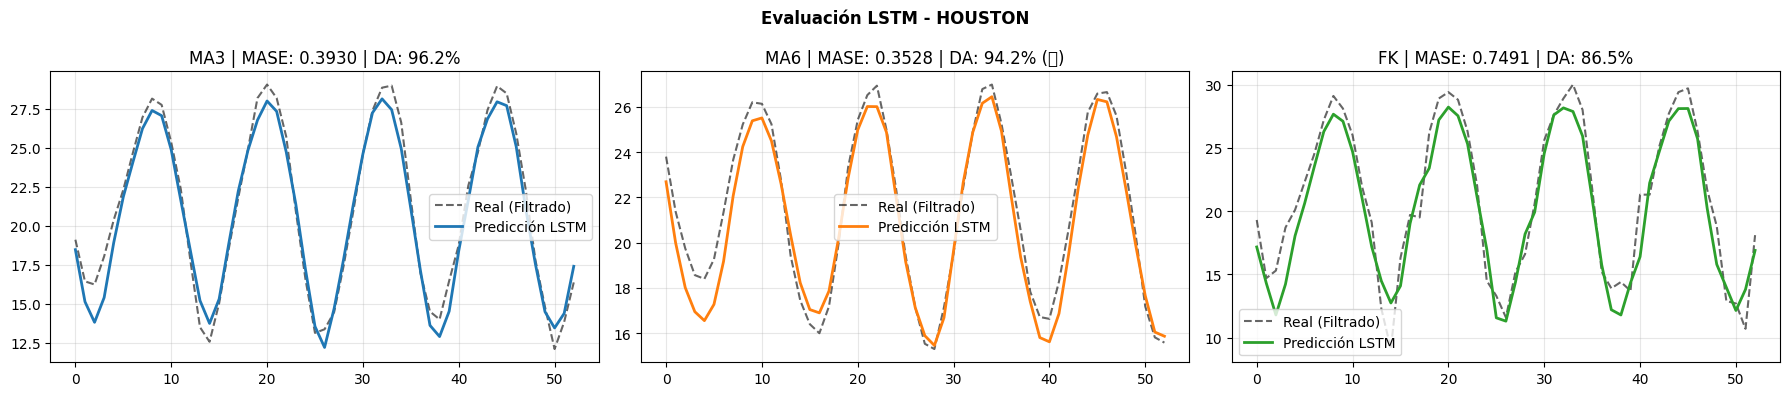


🏙️ EVALUANDO FILTROS PARA: MIAMI
  -> Entrenando LSTM con: MA3...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     RMSE: 0.6521 | MASE: 0.2982 | DA: 94.23%
  -> Entrenando LSTM con: MA6...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     RMSE: 0.8634 | MASE: 0.4564 | DA: 100.00%
  -> Entrenando LSTM con: FK...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     RMSE: 1.2655 | MASE: 0.6492 | DA: 78.85%
🏆 GANADOR (MIAMI): MA3 con MASE de 0.2982


/tmp/ipykernel_22835/207952305.py:111: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


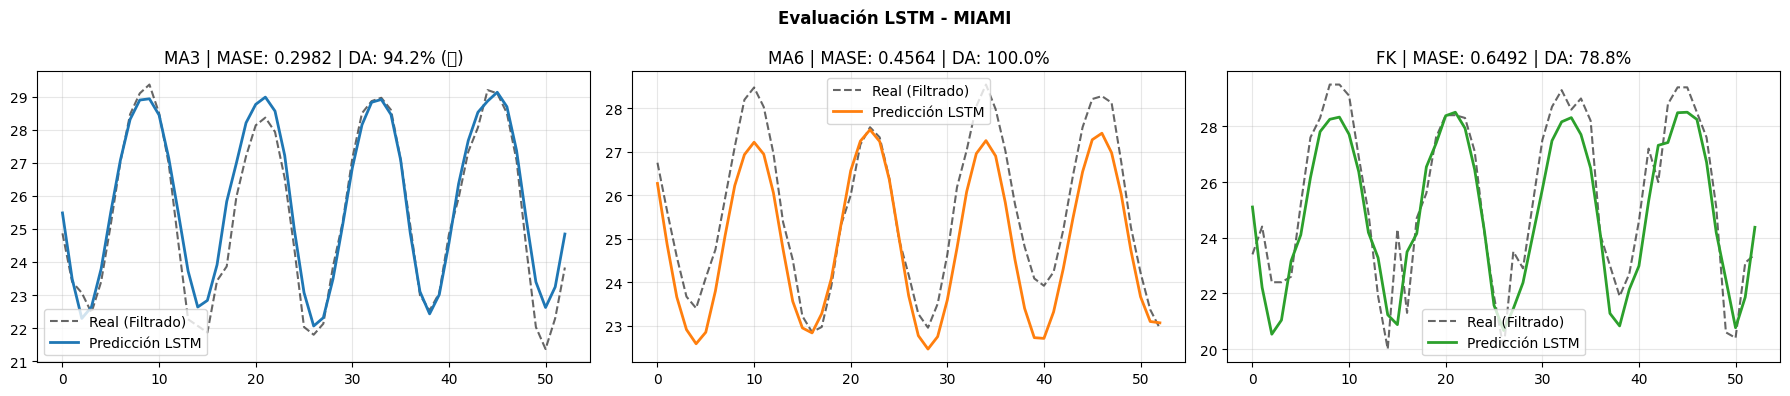


🏙️ EVALUANDO FILTROS PARA: MATAMOROS
  -> Entrenando LSTM con: MA3...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     RMSE: 1.1403 | MASE: 0.4059 | DA: 98.08%
  -> Entrenando LSTM con: MA6...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     RMSE: 0.7585 | MASE: 0.2844 | DA: 90.38%
  -> Entrenando LSTM con: FK...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


     RMSE: 1.6037 | MASE: 0.5102 | DA: 84.62%
🏆 GANADOR (MATAMOROS): MA6 con MASE de 0.2844


/tmp/ipykernel_22835/207952305.py:111: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128081 (\N{CROWN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


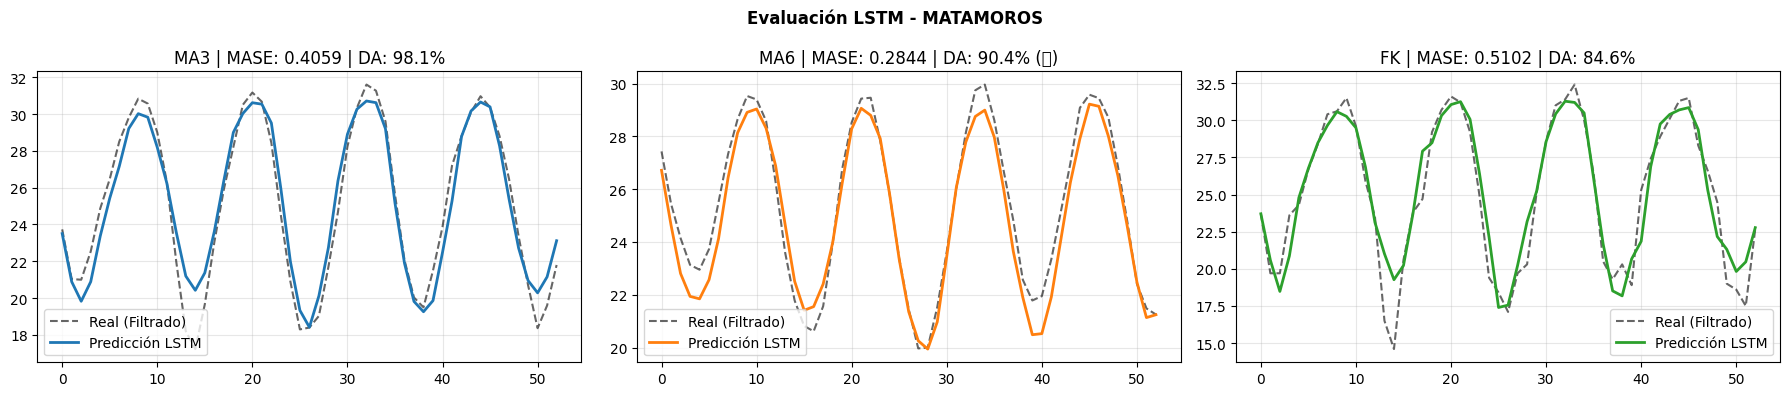

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Bidirectional
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =====================================================================
# BLOQUE 3: ENTRENAMIENTO LSTM Y SELECCIÓN (CON FK Y LOSS=MAE)
# =====================================================================

window_size = 12
filtros_a_probar = ['ma3', 'ma6', 'fk'] # Fk ha regresado al ring

d_factors = {
    'TAMPICO': 1.8244,
    'MIAMI': 1.6542,
    'HOUSTON': 2.1034,
    'MATAMOROS': 2.2104
}

def calc_da(y_true, y_pred):
    return 100 * np.mean(np.sign(np.diff(y_true)) == np.sign(np.diff(y_pred)))

def create_dataset(dataset, look_back=12):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back)])
        Y.append(dataset[i + look_back])
    return np.array(X), np.array(Y)

def build_light_bidirectional_lstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(32, activation='tanh'), input_shape=input_shape),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # CAMBIO CRUCIAL: Usar MAE es equivalente a optimizar MASE en los pesos
    model.compile(optimizer='adam', loss='mae')
    return model

mejores_filtros_por_ciudad = {}
resultados_dlf_etapa1 = {}

for ciudad in ciudades:
    print(f"\n==================================================")
    print(f"🏙️ EVALUANDO FILTROS PARA: {ciudad}")
    print(f"==================================================")

    mejor_score = float('inf') # Buscamos el menor MASE
    mejor_filtro = None
    resultados_ciudad = {}

    for f_key in filtros_a_probar:
        print(f"  -> Entrenando LSTM con: {f_key.upper()}...")

        serie_filtrada = datos_dlf[ciudad][f_key]
        train_f = serie_filtrada[:n_train]
        val_f = serie_filtrada[n_train:n_train + n_val]

        X_train, y_train = create_dataset(train_f, window_size)
        X_val, y_val = create_dataset(val_f, window_size)

        X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
        X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

        model = build_light_bidirectional_lstm((window_size, 1))

        # Subimos epochs a 50 para darle tiempo de salir de la línea recta
        model.fit(X_train, y_train, epochs=50, batch_size=16, verbose=0)

        preds_val = model.predict(X_val, verbose=0).flatten()

        rmse_val = np.sqrt(mean_squared_error(y_val, preds_val))
        mae_val = mean_absolute_error(y_val, preds_val)
        mase_val = mae_val / d_factors[ciudad]
        da_val = calc_da(y_val, preds_val)

        print(f"     RMSE: {rmse_val:.4f} | MASE: {mase_val:.4f} | DA: {da_val:.2f}%")

        resultados_ciudad[f_key] = {
            'y_val': y_val, 'preds': preds_val,
            'rmse': rmse_val, 'mase': mase_val, 'da': da_val, 'model': model
        }

        # Seleccionamos al ganador por MASE
        if mase_val < mejor_score:
            mejor_score = mase_val
            mejor_filtro = f_key

    mejores_filtros_por_ciudad[ciudad] = mejor_filtro
    resultados_dlf_etapa1[ciudad] = resultados_ciudad

    print(f"🏆 GANADOR ({ciudad}): {mejor_filtro.upper()} con MASE de {mejor_score:.4f}")

    # Gráfica de los 3 filtros
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'Evaluación LSTM - {ciudad}', fontsize=12, fontweight='bold')

    colores = ['#1f77b4', '#ff7f0e', '#2ca02c']

    for i, (f_key, color) in enumerate(zip(filtros_a_probar, colores)):
        res = resultados_ciudad[f_key]
        axes[i].plot(res['y_val'], label='Real (Filtrado)', color='black', linestyle='--', alpha=0.6)
        axes[i].plot(res['preds'], label='Predicción LSTM', color=color, linewidth=2)

        title_extra = " (👑)" if f_key == mejor_filtro else ""
        axes[i].set_title(f'{f_key.upper()} | MASE: {res["mase"]:.4f} | DA: {res["da"]:.1f}%{title_extra}')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [10]:
import pandas as pd
import numpy as np

# =====================================================================
# BLOQUE 4: EXTRACCIÓN DEL MEJOR FILTRO Y EXPORTACIÓN A CSV
# =====================================================================

def calc_smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

resultados_etapa1_list = []

print("==================================================")
print("📊 RESUMEN FINAL: MEJORES FILTROS DE TENDENCIA (ETAPA 1)")
print("==================================================")

for ciudad in ciudades:
    # Obtener el filtro ganador dictaminado en el bloque anterior
    mejor_filtro = mejores_filtros_por_ciudad[ciudad]
    res = resultados_dlf_etapa1[ciudad][mejor_filtro]

    y_val = res['y_val']
    preds = res['preds']

    # Recuperar métricas guardadas y calcular el sMAPE
    rmse = res['rmse']
    mase = res['mase']
    da = res['da']
    smape = calc_smape(y_val, preds)

    # Almacenar para el CSV
    resultados_etapa1_list.append({
        'City': ciudad,
        'Best_Filter': mejor_filtro.upper(),
        'RMSE': rmse,
        'sMAPE': smape,
        'MASE': mase,
        'DA': da
    })

    print(f"[{ciudad}] -> GANADOR: {mejor_filtro.upper()}")
    print(f"   RMSE: {rmse:.4f} | sMAPE: {smape:.2f}% | MASE: {mase:.4f} | DA: {da:.2f}%\n")

# Crear DataFrame y exportar
df_mejores_filtros = pd.DataFrame(resultados_etapa1_list)
nombre_archivo = 'DLF_ETAPA1_MEJORES_FILTROS.csv'
df_mejores_filtros.to_csv(nombre_archivo, index=False)

print(f"[ÉXITO] Archivo '{nombre_archivo}' generado y guardado en su entorno de Colab.")

📊 RESUMEN FINAL: MEJORES FILTROS DE TENDENCIA (ETAPA 1)
[TAMPICO] -> GANADOR: MA6
   RMSE: 0.6005 | sMAPE: 2.03% | MASE: 0.2658 | DA: 92.31%

[HOUSTON] -> GANADOR: MA6
   RMSE: 0.9050 | sMAPE: 3.67% | MASE: 0.3528 | DA: 94.23%

[MIAMI] -> GANADOR: MA3
   RMSE: 0.6521 | sMAPE: 1.99% | MASE: 0.2982 | DA: 94.23%

[MATAMOROS] -> GANADOR: MA6
   RMSE: 0.7585 | sMAPE: 2.56% | MASE: 0.2844 | DA: 90.38%

[ÉXITO] Archivo 'DLF_ETAPA1_MEJORES_FILTROS.csv' generado y guardado en su entorno de Colab.


🌪️ ETAPA 2: MODELADO DE RESIDUALES Y RECONSTRUCCIÓN

[TAMPICO] -> Procesando residual del filtro: MA6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 29.
   MÉTRICAS FINALES DLF: RMSE: 1.2911 | sMAPE: 4.18% | MASE: 0.5233 | DA: 84.62%


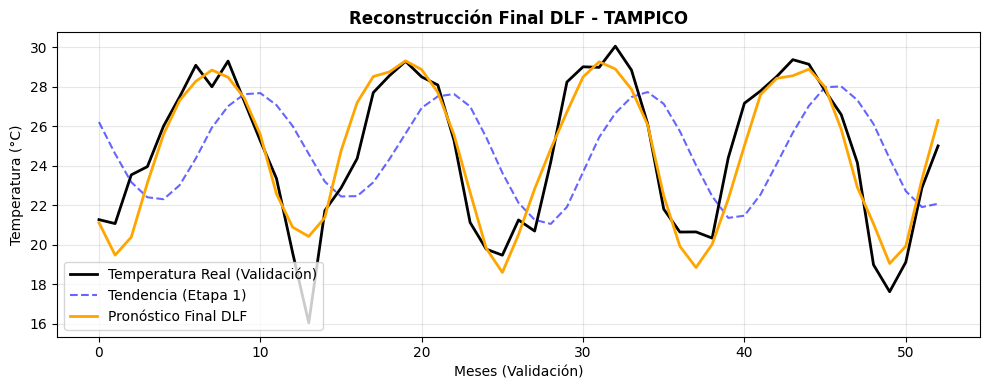


[HOUSTON] -> Procesando residual del filtro: MA6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 39: early stopping
Restoring model weights from the end of the best epoch: 29.
   MÉTRICAS FINALES DLF: RMSE: 1.8529 | sMAPE: 7.98% | MASE: 0.6815 | DA: 82.69%


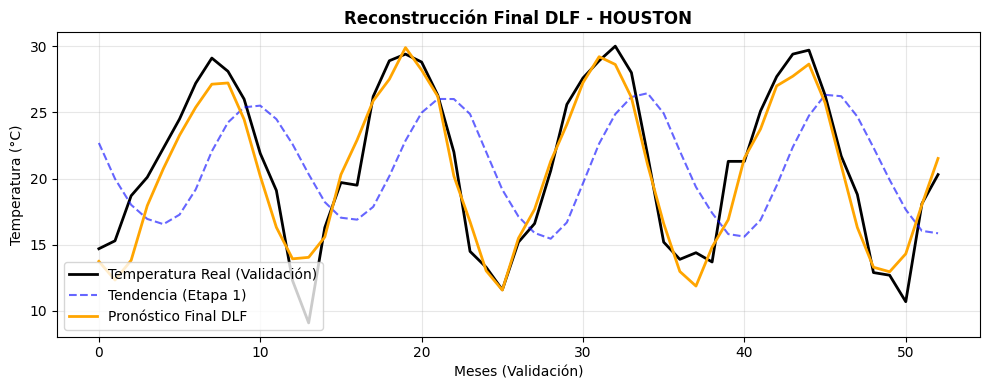


[MIAMI] -> Procesando residual del filtro: MA3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 44: early stopping
Restoring model weights from the end of the best epoch: 34.
   MÉTRICAS FINALES DLF: RMSE: 1.0970 | sMAPE: 3.46% | MASE: 0.5115 | DA: 82.69%


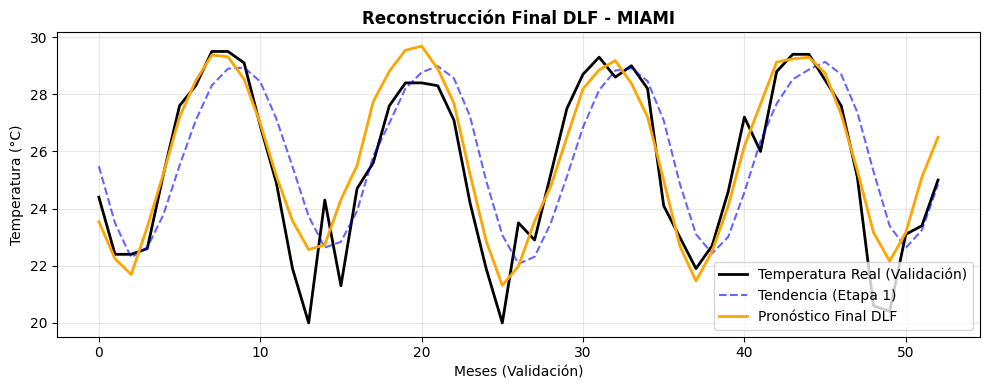


[MATAMOROS] -> Procesando residual del filtro: MA6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 35: early stopping
Restoring model weights from the end of the best epoch: 25.
   MÉTRICAS FINALES DLF: RMSE: 1.5537 | sMAPE: 5.04% | MASE: 0.5137 | DA: 92.31%


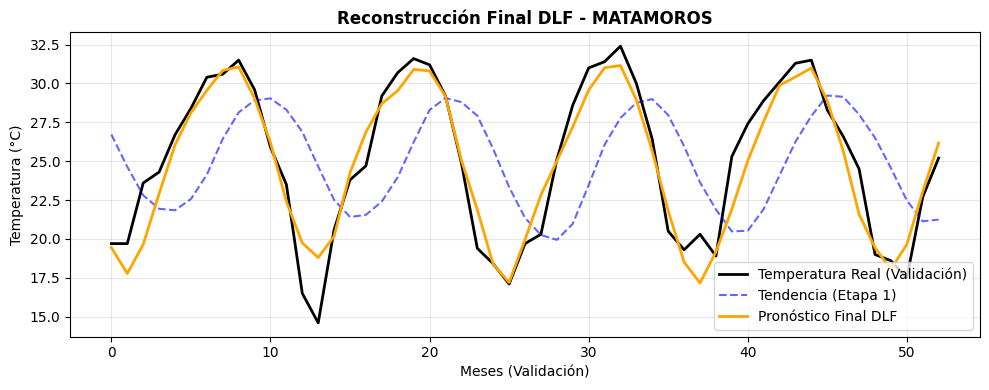


[ÉXITO] Resultados finales guardados en: DLF_METRICAS_FINALES_VALIDACION.csv


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Conv1D, MaxPooling1D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =====================================================================
# BLOQUE 5: ETAPA 2 (RESIDUALES CNN-LSTM) Y RECONSTRUCCIÓN FINAL DLF
# =====================================================================

window_size = 12

def build_residual_cnn_lstm(input_shape):
    """Arquitectura diseñada para extraer patrones de ruido complejo evitando overfitting"""
    model = Sequential([
        # Extrae características locales del ruido (ej. caídas bruscas)
        Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=input_shape),
        MaxPooling1D(pool_size=2),
        # Aprende la secuencia temporal de esas características
        LSTM(32, activation='tanh'),
        # Regularización estricta
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    # Pérdida MAE para consistencia matemática con el MASE
    model.compile(optimizer='adam', loss='mae')
    return model

resultados_dlf_final = []

print("==================================================")
print("🌪️ ETAPA 2: MODELADO DE RESIDUALES Y RECONSTRUCCIÓN")
print("==================================================")

for ciudad in ciudades:
    mejor_filtro = mejores_filtros_por_ciudad[ciudad]
    print(f"\n[{ciudad}] -> Procesando residual del filtro: {mejor_filtro.upper()}")

    # 1. Obtener los residuales específicos de ese filtro
    res_key = f'res_{mejor_filtro}'
    serie_residual = datos_dlf[ciudad][res_key]

    train_res = serie_residual[:n_train]
    val_res = serie_residual[n_train:n_train + n_val]

    # Crear ventanas para el residual
    X_train_res, y_train_res = create_dataset(train_res, window_size)
    X_val_res, y_val_res = create_dataset(val_res, window_size)

    X_train_res = X_train_res.reshape((X_train_res.shape[0], X_train_res.shape[1], 1))
    X_val_res = X_val_res.reshape((X_val_res.shape[0], X_val_res.shape[1], 1))

    # 2. Entrenar modelo CNN-LSTM con Early Stopping (Anti-Overfitting)
    model_res = build_residual_cnn_lstm((window_size, 1))

    # Se detiene si el MAE en validación no mejora en 10 epochs, restaurando el mejor peso
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

    model_res.fit(X_train_res, y_train_res,
                  validation_data=(X_val_res, y_val_res),
                  epochs=100, batch_size=16,
                  callbacks=[early_stop], verbose=0)

    # 3. Predicción del residual en validación
    preds_res_val = model_res.predict(X_val_res, verbose=0).flatten()

    # 4. RECONSTRUCCIÓN (Tendencia de Etapa 1 + Residual de Etapa 2)
    preds_tendencia_val = resultados_dlf_etapa1[ciudad][mejor_filtro]['preds']
    prediccion_final_dlf = preds_tendencia_val + preds_res_val

    # Serie original real (Validación) para comparar
    y_val_real = datos_dlf[ciudad]['val'][window_size:]

    # 5. Calcular Métricas Finales
    rmse_final = np.sqrt(mean_squared_error(y_val_real, prediccion_final_dlf))
    mae_final = mean_absolute_error(y_val_real, prediccion_final_dlf)
    mase_final = mae_final / d_factors[ciudad]
    da_final = calc_da(y_val_real, prediccion_final_dlf)
    smape_final = calc_smape(y_val_real, prediccion_final_dlf)

    print(f"   MÉTRICAS FINALES DLF: RMSE: {rmse_final:.4f} | sMAPE: {smape_final:.2f}% | MASE: {mase_final:.4f} | DA: {da_final:.2f}%")

    resultados_dlf_final.append({
        'City': ciudad,
        'Model': 'DLF Híbrido (Etapa1+Etapa2)',
        'RMSE': rmse_final,
        'sMAPE': smape_final,
        'MASE': mase_final,
        'DA': da_final
    })

    # 6. Gráfica Final de Reconstrucción
    plt.figure(figsize=(10, 4))
    plt.plot(y_val_real, label='Temperatura Real (Validación)', color='black', linewidth=2)
    plt.plot(preds_tendencia_val, label='Tendencia (Etapa 1)', color='blue', linestyle='--', alpha=0.6)
    plt.plot(prediccion_final_dlf, label='Pronóstico Final DLF', color='orange', linewidth=2)
    plt.title(f'Reconstrucción Final DLF - {ciudad}', fontsize=12, fontweight='bold')
    plt.xlabel('Meses (Validación)')
    plt.ylabel('Temperatura (°C)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# =====================================================================
# GUARDAR RESULTADOS FINALES
# =====================================================================
df_dlf_final = pd.DataFrame(resultados_dlf_final)
archivo_dlf = 'DLF_METRICAS_FINALES_VALIDACION.csv'
df_dlf_final.to_csv(archivo_dlf, index=False)

print("\n==================================================")
print(f"[ÉXITO] Resultados finales guardados en: {archivo_dlf}")
print("==================================================")